# IMPORT LIBRARY

In [96]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

# LOAD DATA

In [97]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    sub_folder_files = os.listdir(sub_folder_path)
    for i, filename in enumerate(sub_folder_files):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            continue
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 241
Kelas: ['Corroded', 'Normal']


# FUNCTION PRE-PROCESSING

In [98]:
# ── Resize + Grayscale + Equalisasi ───────────────────────────────────────
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)

def histogram_equalization_grayscale(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()
    equalized_result = cv.equalizeHist(img)
    return equalized_result

def prepro(image):
    img = resize_grayscale(image)
    img = histogram_equalization_grayscale(img)
    return img


# ── Fungsi Dasar ───────────────────────────────────────────────────────────
def gaussian_kernel(size=5, sigma=1.0):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / kernel.sum()

def conv2d(img, kernel):
    ih, iw = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.zeros((ih + 2*pad_h, iw + 2*pad_w), dtype=np.float64)
    padded[pad_h:pad_h+ih, pad_w:pad_w+iw] = img

    output = np.zeros_like(img, dtype=np.float64)
    for i in range(ih):
        for j in range(iw):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output


# ── Sharpening ─────────────────────────────────────────────────────────────
def sharpen_unsharp_manual(img, strength=1.5):
    img_float = img.astype(np.float64)
    kernel    = gaussian_kernel(size=5, sigma=1.0)
    blurred   = conv2d(img_float, kernel)
    sharpened = img_float + strength * (img_float - blurred)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


# ── Gaussian Blur ──────────────────────────────────────────────────────────
def gaussian_blur_manual(img, size=5, sigma=1.0):
    img_float = img.astype(np.float64)
    kernel    = gaussian_kernel(size=size, sigma=sigma)
    blurred   = conv2d(img_float, kernel)
    return np.clip(blurred, 0, 255).astype(np.uint8)


# ── Fungsi Visualisasi ─────────────────────────────────────────────────────
def visualisasi_grid(data_img, labels, unique_labels, judul=''):
    for label in unique_labels:
        idxs = [j for j, l in enumerate(labels) if l == label]

        fig, axs = plt.subplots(4, 6, figsize=(12, 8))
        fig.suptitle(f'{judul} — {label}' if judul else f'{label}', fontsize=16)

        for k in range(min(24, len(idxs))):
            row = k // 6
            col = k % 6
            ax  = axs[row][col]

            ax.imshow(data_img[idxs[k]], cmap='gray')
            ax.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

# VISUALISASI DATA

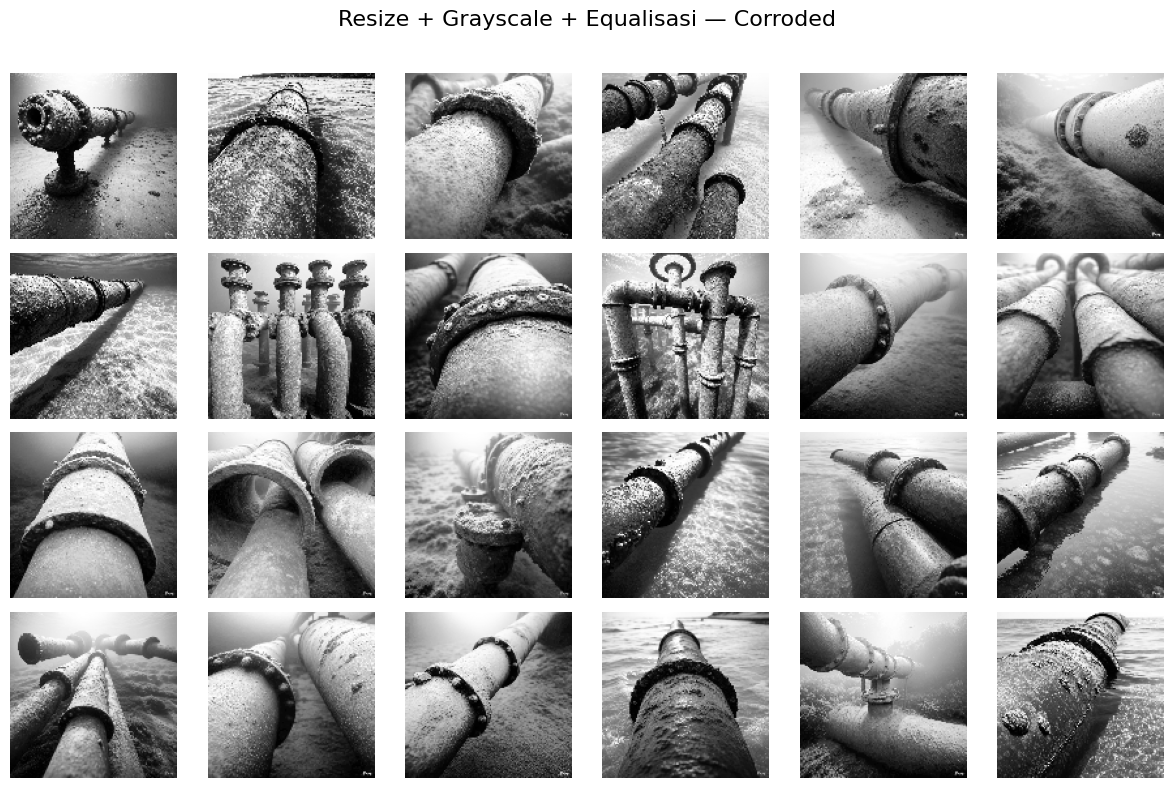

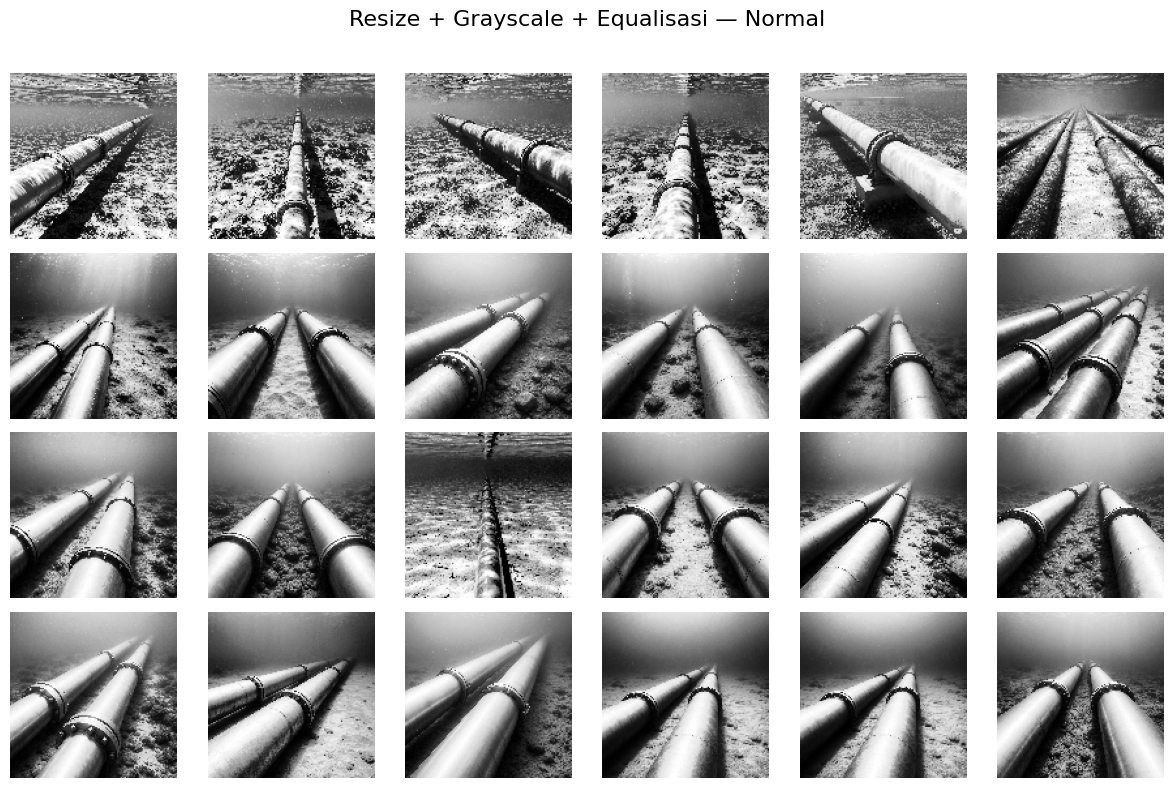

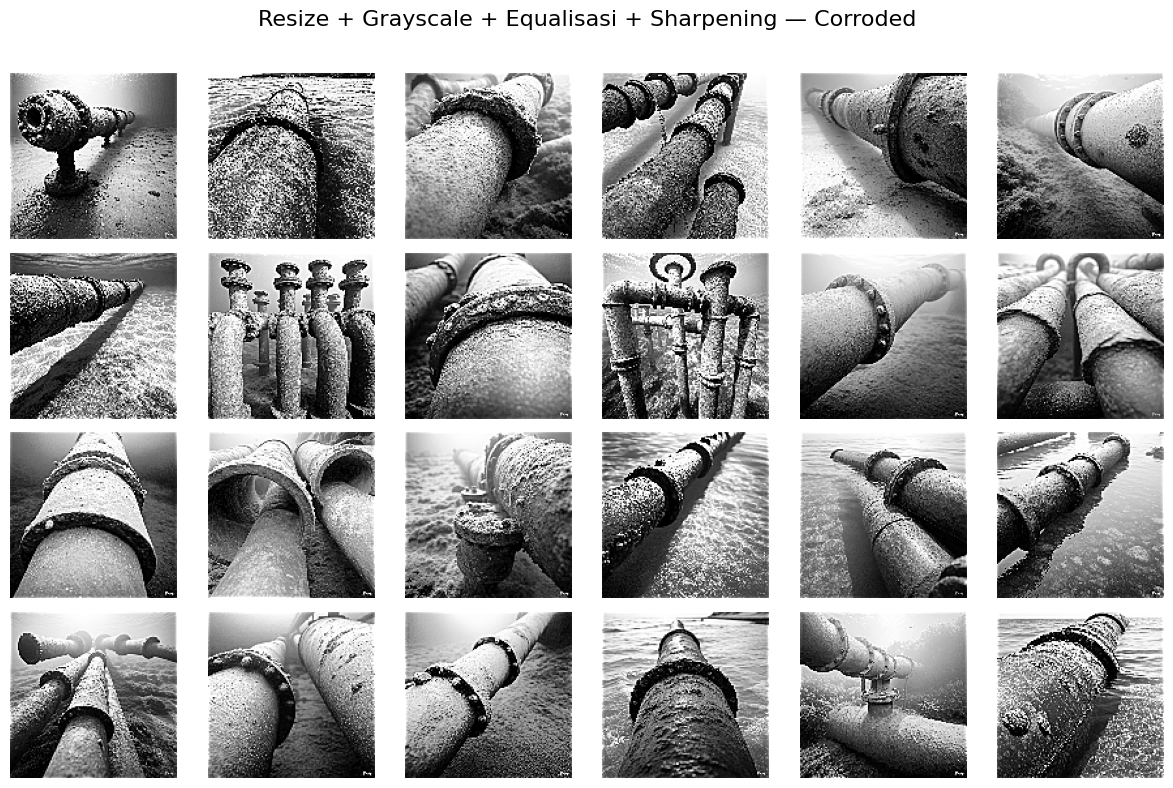

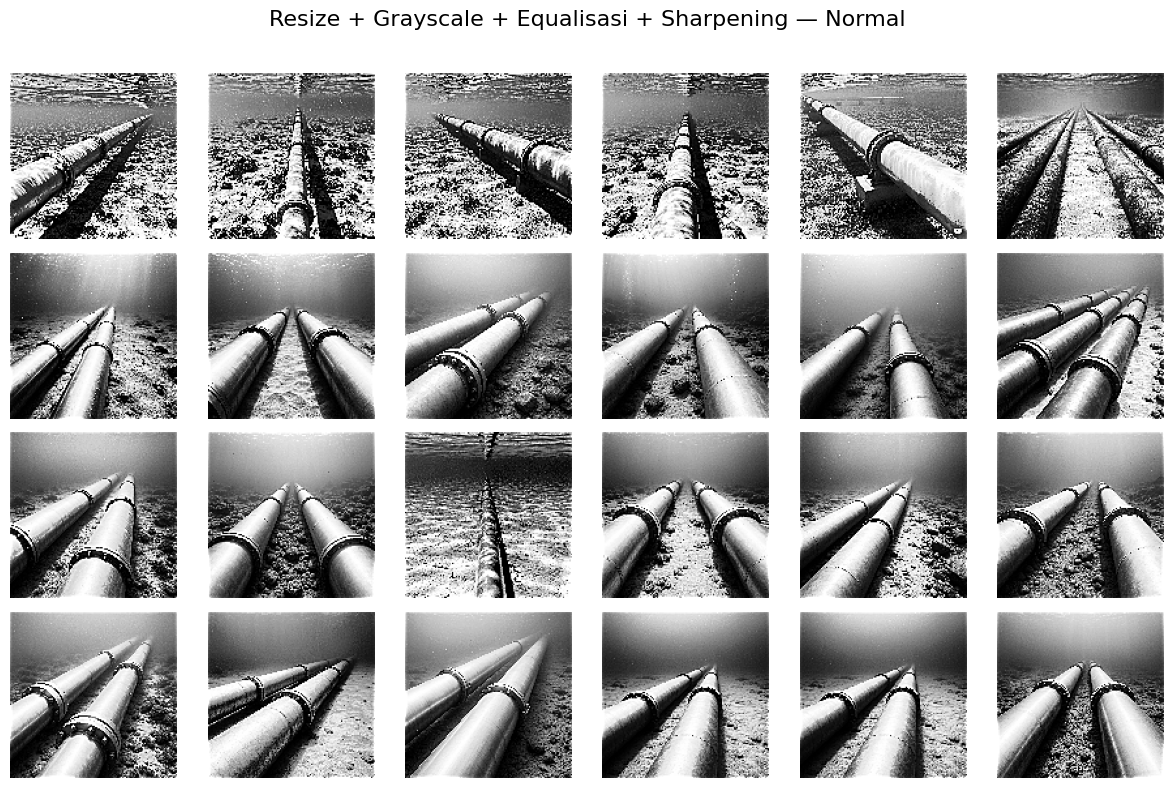

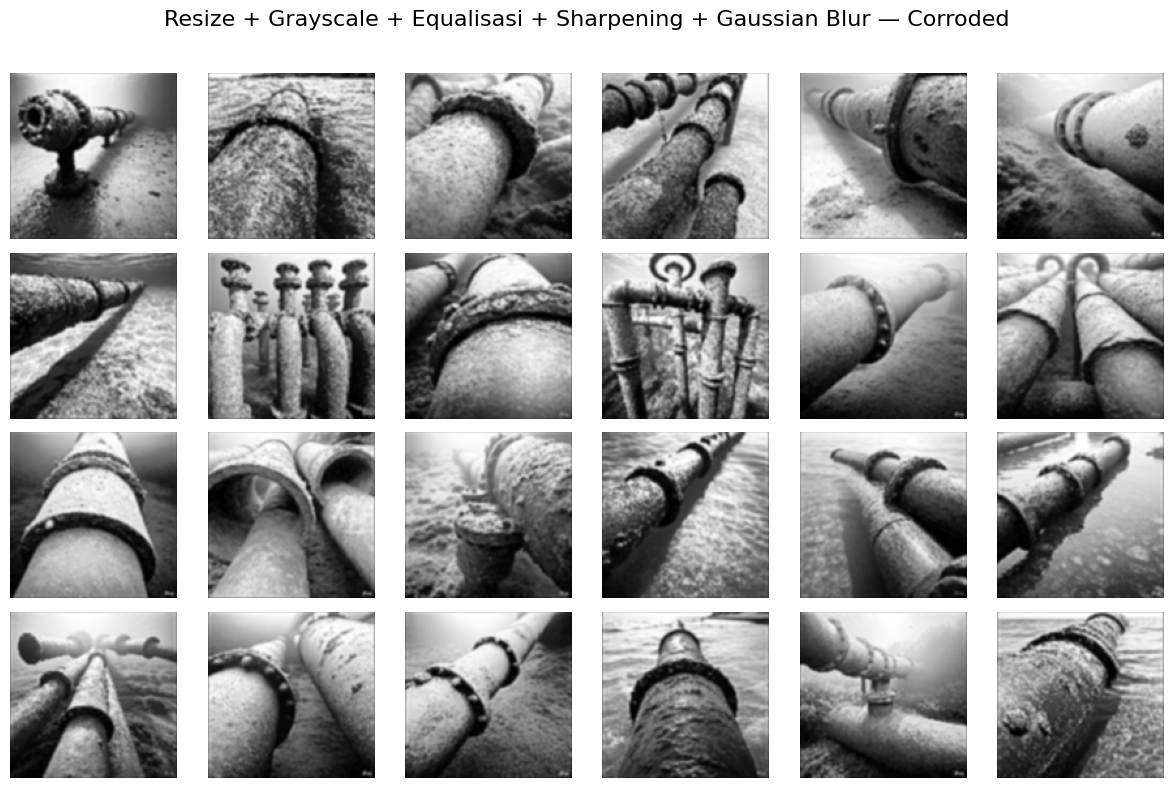

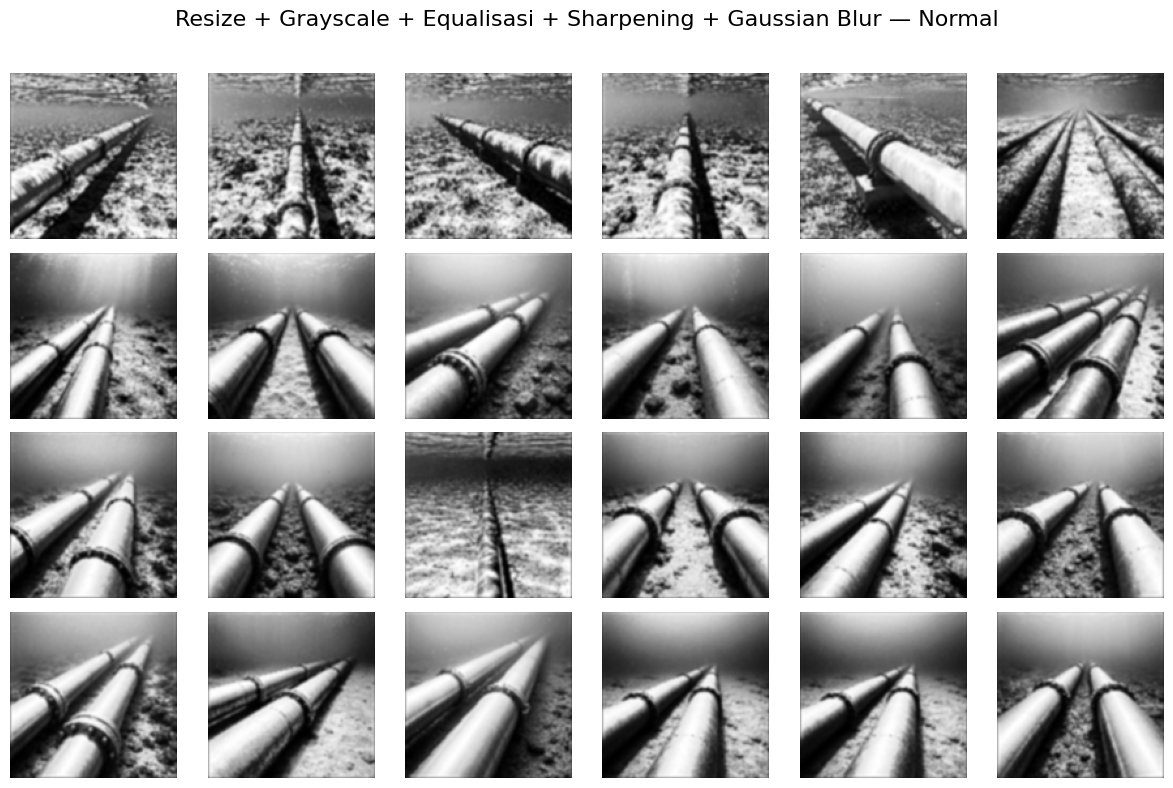

In [99]:
# ── Pipeline Data ──────────────────────────────────────────────────────────
unique_labels    = sorted(set(labels))
dataPreprocessed = [prepro(img) for img in data]
dataSharpened    = [sharpen_unsharp_manual(img) for img in dataPreprocessed]
dataBlurred      = [gaussian_blur_manual(img) for img in dataSharpened]


# ── Visualisasi ────────────────────────────────────────────────────────────
visualisasi_grid(dataPreprocessed, labels, unique_labels,
                 judul='Resize + Grayscale + Equalisasi')

visualisasi_grid(dataSharpened, labels, unique_labels,
                 judul='Resize + Grayscale + Equalisasi + Sharpening')

visualisasi_grid(dataBlurred, labels, unique_labels,
                 judul='Resize + Grayscale + Equalisasi + Sharpening + Gaussian Blur')

# FUNGSI EKSTRAKSI FITUR GLCM

In [100]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# EKSTRAKSI FITUR GLCM

In [101]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataBlurred)):
    D0   = glcm(dataBlurred[i], 0)
    D45  = glcm(dataBlurred[i], 45)
    D90  = glcm(dataBlurred[i], 90)
    D135 = glcm(dataBlurred[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataBlurred)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataBlurred)} citra.")

Ekstraksi fitur selesai untuk 241 citra.


# EKSTRAKSI KE CSV

In [102]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)

#save to csv
os.makedirs('./hasil_ekstraksi', exist_ok=True)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi_P3.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi_P3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,001.jpg,Corroded,176.452694,350.927522,213.124323,385.140120,0.210829,0.145551,0.243387,0.172948,...,0.000252,0.000196,0.016265,0.013452,0.015883,0.013991,0.981660,0.963634,0.977811,0.960090
1,002.jpg,Corroded,237.155696,564.022568,398.115219,610.089776,0.109424,0.073821,0.085205,0.064136,...,0.000118,0.000098,0.011837,0.010173,0.010883,0.009891,0.967449,0.922378,0.944949,0.916048
2,003.jpg,Corroded,127.105130,282.399095,178.935962,296.742017,0.169359,0.120274,0.144630,0.110323,...,0.000161,0.000127,0.013609,0.011579,0.012682,0.011265,0.987172,0.971551,0.981913,0.970104
3,004.jpg,Corroded,271.500369,561.025172,267.285002,453.730671,0.135122,0.095005,0.130270,0.115185,...,0.000152,0.000128,0.012637,0.010957,0.012313,0.011303,0.968552,0.935067,0.968940,0.947485
4,005.jpg,Corroded,101.127276,237.014074,142.077325,224.831298,0.197666,0.175363,0.189013,0.124190,...,0.000208,0.000152,0.014987,0.013463,0.014432,0.012342,0.989723,0.975975,0.985592,0.977211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,116.png,Normal,213.610359,511.203670,330.451095,524.216442,0.207914,0.178676,0.221467,0.202206,...,0.000242,0.000230,0.016400,0.013642,0.015564,0.015177,0.977977,0.947564,0.966166,0.946226
237,117.png,Normal,185.172121,671.363507,345.380352,344.600223,0.176089,0.096675,0.138145,0.192217,...,0.000175,0.000204,0.014348,0.011186,0.013213,0.014295,0.981687,0.933761,0.965797,0.966003
238,118.png,Normal,148.666523,370.906690,173.002030,251.341993,0.264952,0.160531,0.209892,0.219021,...,0.000281,0.000260,0.017546,0.013702,0.016762,0.016134,0.985516,0.964026,0.983228,0.975624
239,119.png,Normal,123.557702,427.105462,203.657296,199.817224,0.236293,0.173385,0.167096,0.198220,...,0.000244,0.000262,0.016929,0.013477,0.015629,0.016177,0.988013,0.958757,0.980368,0.980703


# FEATURE SELECTION

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 16
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Dissimilarity135', 'Entropy0', 'Entropy45', 'Entropy90', 'ASM0']


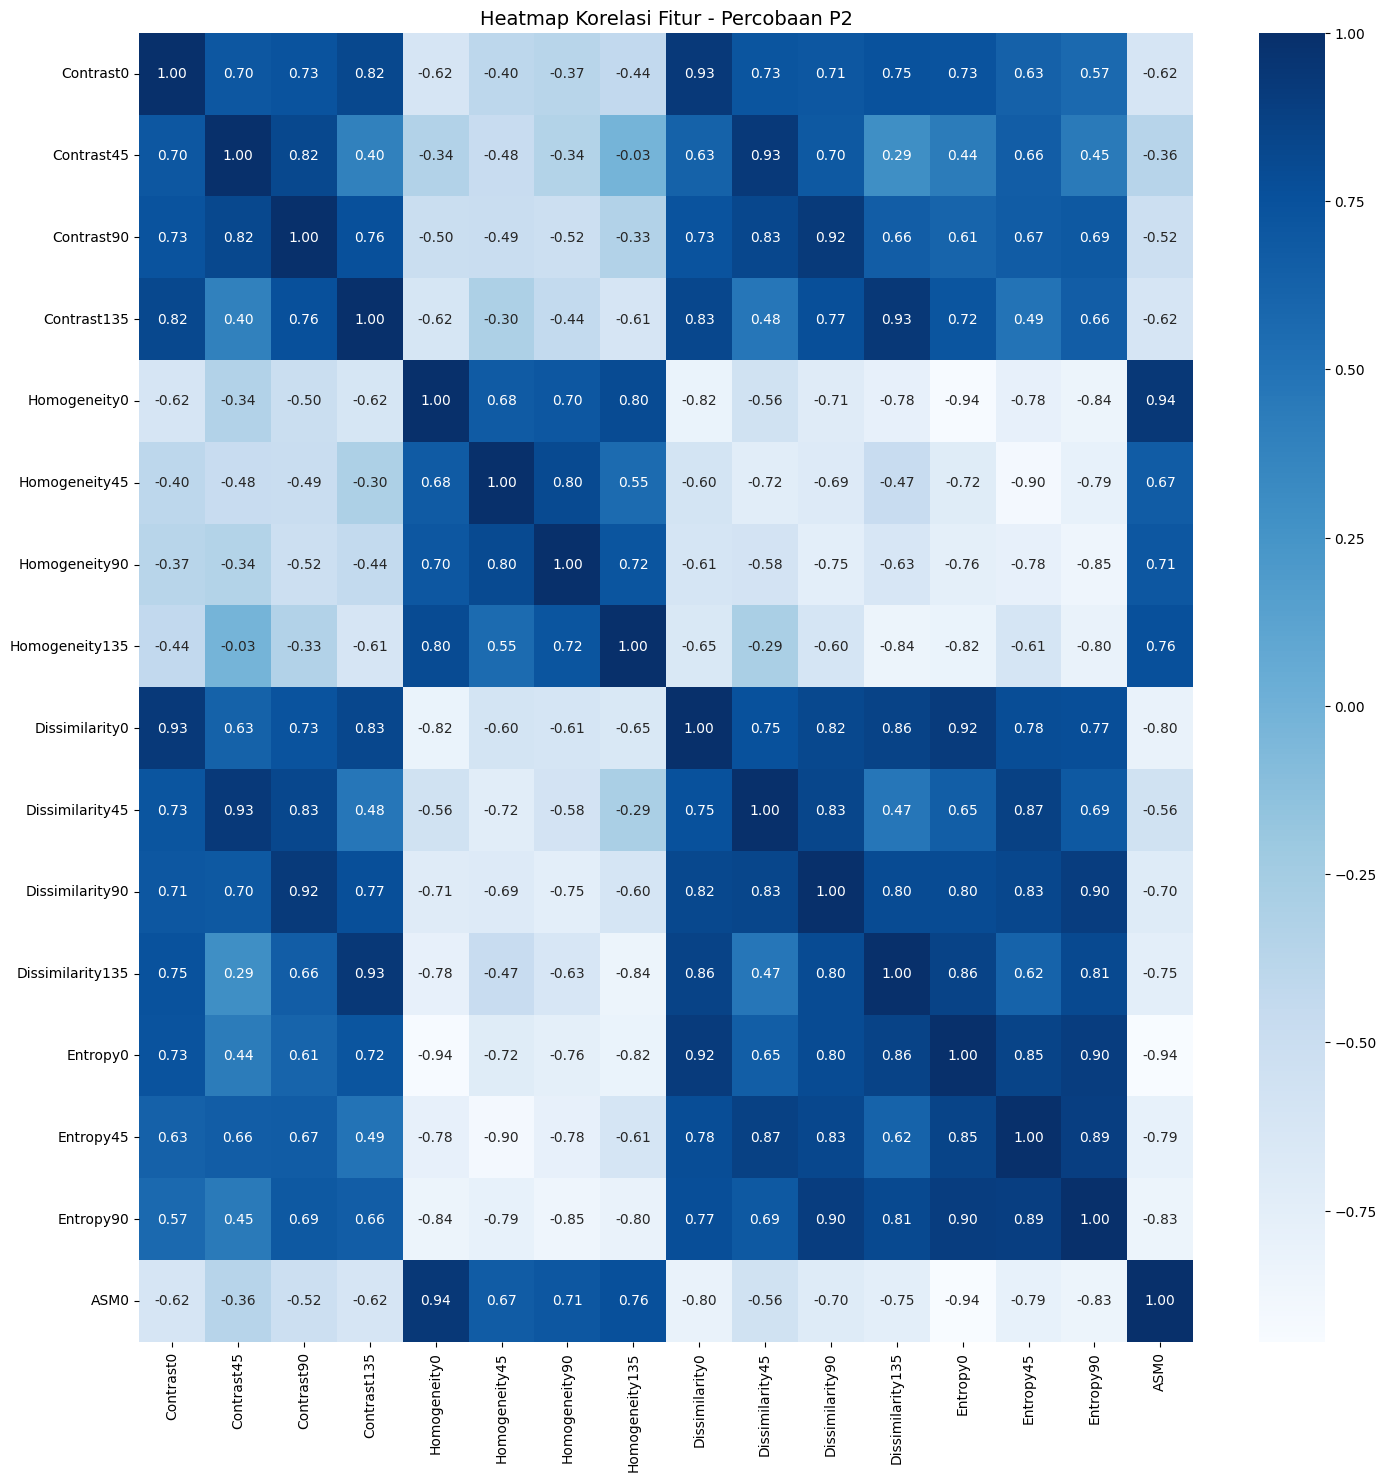

In [103]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan P2', fontsize=14)
plt.show()

# SPLITTING DATA

In [104]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(192, 16)
(49, 16)


Kode ini digunakan untuk membagi data menjadi data latih (training set) dan data uji (testing set) dengan proporsi 80:20 menggunakan fungsi train_test_split(). Parameter test_size=0.2 berarti 20% data dialokasikan untuk pengujian, sedangkan random_state=42 digunakan agar hasil pembagian data bersifat konsisten dan dapat direproduksi setiap kali notebook dijalankan ulang. Shape dari X_train dan X_test dicetak untuk memastikan jumlah data pada masing-masing set sudah sesuai dengan proporsi yang diinginkan.

# NORMALISASI FITUR

In [105]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

# MODELING: Define Model

In [106]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# HASIL MODELING RANDOM FOREST

In [107]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Corroded       1.00      1.00      1.00        95
      Normal       1.00      1.00      1.00        97

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192

[[95  0]
 [ 0 97]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.92      0.88      0.90        26
      Normal       0.88      0.91      0.89        23

    accuracy                           0.90        49
   macro avg       0.90      0.90      0.90        49
weighted avg       0.90      0.90      0.90        49

[[23  3]
 [ 2 21]]
Accuracy: 0.8979591836734694


## HASIL MODELING SVM

In [108]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.96      0.95      0.95        95
      Normal       0.95      0.96      0.95        97

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192

[[90  5]
 [ 4 93]]
Accuracy: 0.953125

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.92      0.88      0.90        26
      Normal       0.88      0.91      0.89        23

    accuracy                           0.90        49
   macro avg       0.90      0.90      0.90        49
weighted avg       0.90      0.90      0.90        49

[[23  3]
 [ 2 21]]
Accuracy: 0.8979591836734694


# HASIL MODELING KNN

In [109]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.96      0.93      0.94        95
      Normal       0.93      0.96      0.94        97

    accuracy                           0.94       192
   macro avg       0.94      0.94      0.94       192
weighted avg       0.94      0.94      0.94       192

[[88  7]
 [ 4 93]]
Accuracy: 0.9427083333333334

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.85      0.88      0.87        26
      Normal       0.86      0.83      0.84        23

    accuracy                           0.86        49
   macro avg       0.86      0.86      0.86        49
weighted avg       0.86      0.86      0.86        49

[[23  3]
 [ 4 19]]
Accuracy: 0.8571428571428571


# EVALUASI CONFUSION MATRIX

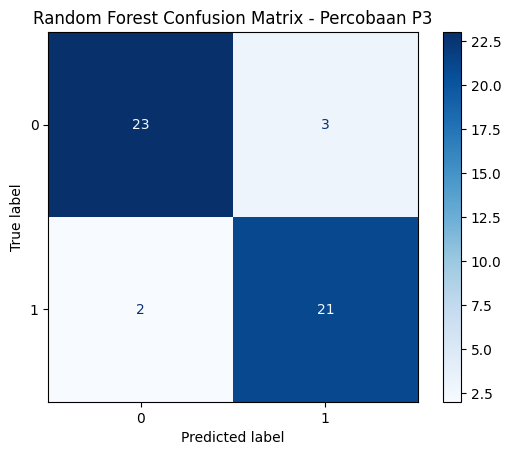

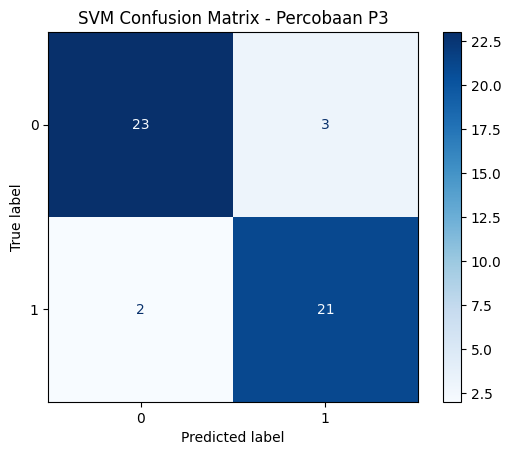

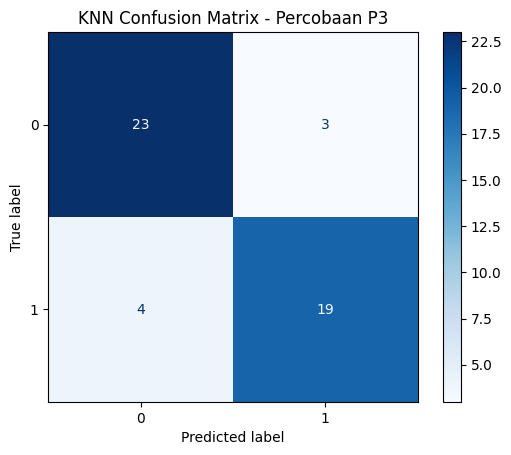

In [110]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan P3")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan P3")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan P3")

# HASIL KLASIFIKASI

In [111]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)

#save to csv
os.makedirs('./hasil_klasifikasi', exist_ok=True)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi_P3.csv', index=False)
print("File hasil_klasifikasi_P3.csv berhasil disimpan!")
df_hasil

File hasil_klasifikasi_P3.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,1.000000,0.897959,0.898878,0.897959,0.898044
1,SVM,0.953125,0.897959,0.898878,0.897959,0.898044
2,KNN,0.942708,0.857143,0.857383,0.857143,0.856903
